### 1. Làm sạch dữ liệu


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Đọc dữ liệu 2024 toàn bộ
df_q1_24 = pd.read_csv('Sales_Q1_2024_VN.csv')
df_q2_24 = pd.read_csv('Sales_Q2_2024_VN.csv')
df_q3_24 = pd.read_csv('Sales_Q3_2024_VN.csv')
df_q4_24 = pd.read_csv('Sales_Q4_2024_VN.csv')
df1 = pd.concat([df_q1_24, df_q2_24, df_q3_24, df_q4_24], ignore_index=True)

In [4]:
# Đọc dữ liệu 2025 toàn bộ
df_q1_25 = pd.read_csv('Sales_Q1_2025_VN.csv')
df_q2_25 = pd.read_csv('Sales_Q2_2025_VN.csv')
df2 = pd.concat([df_q1_25, df_q2_25], ignore_index=True)

In [5]:
df1.isnull().sum()

OrderID       0
OrderDate     0
ProductID     0
CustomerID    0
BranchID      0
Quantity      0
Revenue       0
Profit        0
Channel       0
dtype: int64

In [6]:
df2.isnull().sum()

OrderID       0
OrderDate     0
ProductID     0
CustomerID    0
BranchID      0
Quantity      0
Revenue       0
Profit        0
Channel       0
dtype: int64

In [7]:
df1 = df1.dropna()
df2 = df2.dropna()

In [8]:
# xử lý dữ liệu trùng lặp
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()

In [9]:
df1.dtypes

OrderID        object
OrderDate      object
ProductID      object
CustomerID     object
BranchID       object
Quantity        int64
Revenue       float64
Profit        float64
Channel        object
dtype: object

In [10]:
df2.dtypes

OrderID        object
OrderDate      object
ProductID      object
CustomerID     object
BranchID       object
Quantity        int64
Revenue       float64
Profit        float64
Channel        object
dtype: object

In [11]:
# Chuyển sang datetime ( dd/mm/yyyy, nếu lỗi → chuyển thành NaT (tránh crash))
df1['OrderDate'] = pd.to_datetime(df1['OrderDate'], dayfirst=True, errors='coerce')


In [12]:
# Chuyển sang datetime ( dd/mm/yyyy, nếu lỗi → chuyển thành NaT (tránh crash))
df2['OrderDate'] = pd.to_datetime(df2['OrderDate'], dayfirst=True, errors='coerce')

C:\Users\THANH HIEN\AppData\Local\Temp\ipykernel_29792\4290526632.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df2['OrderDate'] = pd.to_datetime(df2['OrderDate'], dayfirst=True, errors='coerce')


In [13]:
df2.dtypes

OrderID               object
OrderDate     datetime64[ns]
ProductID             object
CustomerID            object
BranchID              object
Quantity               int64
Revenue              float64
Profit               float64
Channel               object
dtype: object

In [14]:
df1 = df1.dropna(subset=['OrderDate'])
df2 = df2.dropna(subset=['OrderDate'])

In [15]:
# định dạng ngày tháng 
df1['Year'] = df1['OrderDate'].dt.year
df1['Month'] = df1['OrderDate'].dt.month
df1['Quarter'] = df1['OrderDate'].dt.quarter

In [16]:
# định dạng ngày tháng 
df2['Year'] = df2['OrderDate'].dt.year
df2['Month'] = df2['OrderDate'].dt.month
df2['Quarter'] = df2['OrderDate'].dt.quarter

In [17]:
# recheck
df2.shape
df2.head(5)

,OrderID,OrderDate,ProductID,CustomerID,BranchID,Quantity,Revenue,Profit,Channel,Year,Month,Quarter
0,2025-Q1-00001,2025-02-13,AC-15HP-CS,C064,B02,1,10821000.0,1680000.0,Offline,2025,2,1
1,2025-Q1-00002,2025-01-12,MW-PANA-25,C090,B15,2,6129000.0,1051000.0,Online,2025,1,1
2,2025-Q1-00003,2025-03-12,AC-1HP-CS,C043,B10,1,8844000.0,1590000.0,Online,2025,3,1
3,2025-Q1-00004,2025-02-03,WH-ARIST-30,C016,B10,2,6589000.0,1135000.0,Offline,2025,2,1
4,2025-Q1-00005,2025-02-18,AIR-PURI-60,C065,B05,2,14739000.0,2365000.0,Online,2025,2,1


In [18]:
# kiểm tra dữ liệu có đúng logic k
df1.describe()

,OrderDate,Quantity,Revenue,Profit,Year,Month,Quarter
count,1047,1047.000000,1.047000e+03,1.047000e+03,1047.0,1047.000000,1047.000000
mean,2024-06-21 13:38:20.286532864,1.495702,6.279188e+06,9.446199e+05,2024.0,6.491882,2.495702
min,2024-01-01 00:00:00,1.000000,5.190000e+05,7.200000e+04,2024.0,1.000000,1.000000
25%,2024-04-01 00:00:00,1.000000,2.170000e+06,3.260000e+05,2024.0,4.000000,2.000000
50%,2024-07-01 00:00:00,1.000000,4.438000e+06,6.580000e+05,2024.0,7.000000,3.000000
75%,2024-09-11 00:00:00,2.000000,8.690500e+06,1.323000e+06,2024.0,9.000000,3.000000
max,2024-12-12 00:00:00,3.000000,2.395100e+07,4.051000e+06,2024.0,12.000000,4.000000
std,NaN,0.645421,5.386645e+06,8.254098e+05,0.0,3.383923,1.109549


In [19]:
# kiểm tra dữ liệu có đúng logic k
df2.describe()

,OrderDate,Quantity,Revenue,Profit,Year,Month,Quarter
count,1320,1320.000000,1.320000e+03,1.320000e+03,1320.0,1320.000000,1320.000000
mean,2025-04-03 17:29:27.272727296,1.468939,6.264315e+06,9.382121e+05,2025.0,3.601515,1.530303
min,2025-01-01 00:00:00,1.000000,5.460000e+05,7.400000e+04,2025.0,1.000000,1.000000
25%,2025-02-18 00:00:00,1.000000,2.134000e+06,3.170000e+05,2025.0,2.000000,1.000000
50%,2025-04-06 00:00:00,1.000000,4.419000e+06,6.490000e+05,2025.0,4.000000,2.000000
75%,2025-05-20 00:00:00,2.000000,8.869500e+06,1.291000e+06,2025.0,5.000000,2.000000
max,2025-06-30 00:00:00,3.000000,2.408700e+07,3.908000e+06,2025.0,6.000000,2.000000
std,NaN,0.643817,5.418301e+06,8.205567e+05,0.0,1.721381,0.499270


In [20]:
df1.info()
df1.head()
df1.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1047 entries, 0 to 2629
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     1047 non-null   object        
 1   OrderDate   1047 non-null   datetime64[ns]
 2   ProductID   1047 non-null   object        
 3   CustomerID  1047 non-null   object        
 4   BranchID    1047 non-null   object        
 5   Quantity    1047 non-null   int64         
 6   Revenue     1047 non-null   float64       
 7   Profit      1047 non-null   float64       
 8   Channel     1047 non-null   object        
 9   Year        1047 non-null   int32         
 10  Month       1047 non-null   int32         
 11  Quarter     1047 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(5)
memory usage: 94.1+ KB


(1047, 12)

In [21]:
df2.info()
df2.head()
df2.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     1320 non-null   object        
 1   OrderDate   1320 non-null   datetime64[ns]
 2   ProductID   1320 non-null   object        
 3   CustomerID  1320 non-null   object        
 4   BranchID    1320 non-null   object        
 5   Quantity    1320 non-null   int64         
 6   Revenue     1320 non-null   float64       
 7   Profit      1320 non-null   float64       
 8   Channel     1320 non-null   object        
 9   Year        1320 non-null   int32         
 10  Month       1320 non-null   int32         
 11  Quarter     1320 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(5)
memory usage: 108.4+ KB


(1320, 12)

In [69]:
# gộp bảng 
df1['Year'] = 2024
df2['Year'] = 2025

df = pd.concat([df1, df2], ignore_index=True)
df.tail(10)

,OrderID,OrderDate,ProductID,CustomerID,BranchID,Quantity,Revenue,Profit,Channel,Year,Month,Quarter
2357,2025-Q2-00691,2025-05-26,AC-1HP-CP,C029,B11,1,6222000.0,818000.0,Online,2025,5,2
2358,2025-Q2-00692,2025-06-28,AC-1HP-CS,C084,B13,1,8646000.0,1092000.0,Offline,2025,6,2
2359,2025-Q2-00693,2025-04-13,RC-SHARP-20,C036,B18,3,5225000.0,935000.0,Offline,2025,4,2
2360,2025-Q2-00694,2025-06-12,AIR-PURI-60,C042,B19,1,7078000.0,977000.0,Offline,2025,6,2
2361,2025-Q2-00695,2025-04-29,MW-SHARP-23,C020,B03,1,2300000.0,331000.0,Offline,2025,4,2
2362,2025-Q2-00696,2025-05-12,AC-15HP-CP,C069,B09,1,7114000.0,1068000.0,Offline,2025,5,2
2363,2025-Q2-00697,2025-06-17,AC-15HP-CS,C021,B07,2,21367000.0,2943000.0,Offline,2025,6,2
2364,2025-Q2-00698,2025-05-04,VAC-ELUX-18,C048,B10,1,2114000.0,327000.0,Online,2025,5,2
2365,2025-Q2-00699,2025-06-09,AC-1HP-CS,C044,B01,1,9536000.0,1592000.0,Offline,2025,6,2
2366,2025-Q2-00700,2025-06-19,AC-1HP-CP,C074,B04,2,12147000.0,2103000.0,Online,2025,6,2


In [23]:
df.to_csv('Cleaned_Sales.csv', index=False)

In [24]:
df1['OrderDate'] = pd.to_datetime(df1['OrderDate'], dayfirst=True, errors='coerce')
df1 = df1.dropna(subset=['OrderDate'])

In [25]:
df2['OrderDate'] = pd.to_datetime(df2['OrderDate'], dayfirst=True, errors='coerce')
df2 = df2.dropna(subset=['OrderDate'])

In [26]:
# tạo cột year
df1['Year'] = df1['OrderDate'].dt.year
df2['Year'] = df2['OrderDate'].dt.year

In [27]:
df2[['OrderDate', 'Year']].head()

,OrderDate,Year
0,2025-02-13,2025
1,2025-01-12,2025
2,2025-03-12,2025
3,2025-02-03,2025
4,2025-02-18,2025


In [28]:
df.groupby('Year')['Revenue'].sum()

Year
2024    6.574310e+09
2025    8.268896e+09
Name: Revenue, dtype: float64

### 2. Thống kê mô tả 

<Axes: >

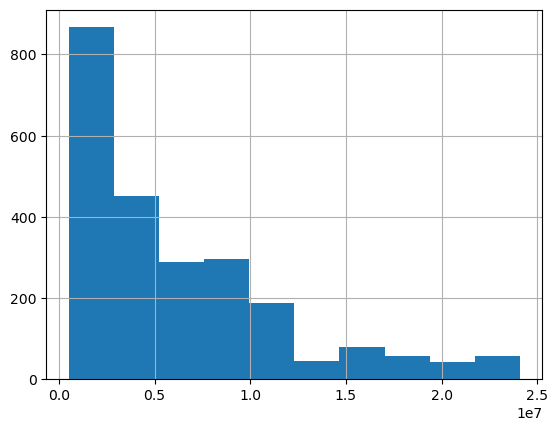

In [29]:
# 2.1 Phân phối dữ liệu
df['Revenue'].hist()

In [30]:
# 2.2 mean - median - mode 
df['Revenue'].mean()


6270893.958597381

In [31]:
df['Revenue'].median()

4430000.0

<Axes: >

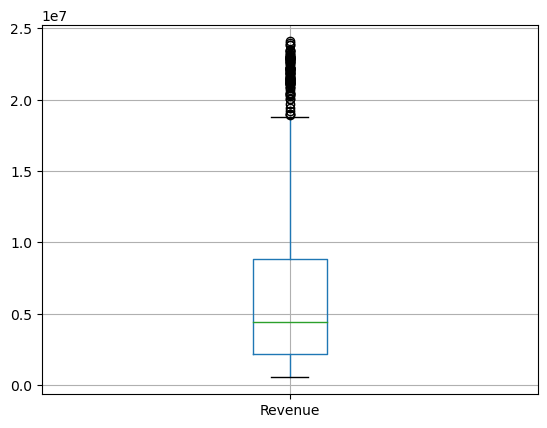

In [71]:
# 2.3 boxplot 
df.boxplot(column='Revenue')


<Axes: >

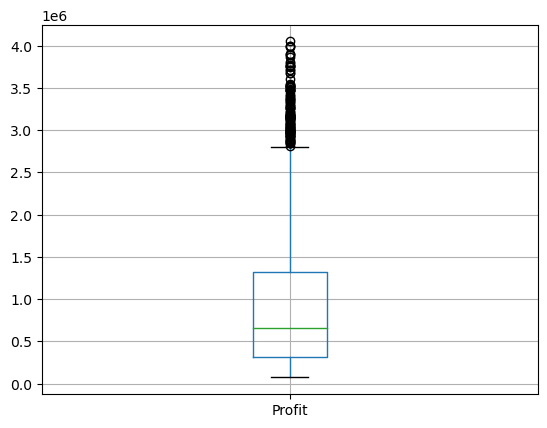

In [72]:
df.boxplot(column = 'Profit' )

#### => Dữ liệu bị ảnh hưởng nhiều bởi các giá trị ngoại lai

In [33]:
# 2.4 phân phối theo năm 
# df.groupby('Year')['Revenue'].describe()
df.groupby('Year')['Revenue'].sum()

Year
2024    6.574310e+09
2025    8.268896e+09
Name: Revenue, dtype: float64

In [34]:
# 2.5 bảng tần suất 
df['Quantity'].value_counts()

Quantity
1    1425
2     746
3     196
Name: count, dtype: int64

In [35]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     2367 non-null   object        
 1   OrderDate   2367 non-null   datetime64[ns]
 2   ProductID   2367 non-null   object        
 3   CustomerID  2367 non-null   object        
 4   BranchID    2367 non-null   object        
 5   Quantity    2367 non-null   int64         
 6   Revenue     2367 non-null   float64       
 7   Profit      2367 non-null   float64       
 8   Channel     2367 non-null   object        
 9   Year        2367 non-null   int64         
 10  Month       2367 non-null   int32         
 11  Quarter     2367 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2), object(5)
memory usage: 203.5+ KB


,OrderDate,Quantity,Revenue,Profit,Year,Month,Quarter
count,2367,2367.000000,2.367000e+03,2.367000e+03,2367.000000,2367.000000,2367.000000
mean,2024-11-28 03:37:11.178707200,1.480777,6.270894e+06,9.410465e+05,2024.557668,4.880017,1.957330
min,2024-01-01 00:00:00,1.000000,5.190000e+05,7.200000e+04,2024.000000,1.000000,1.000000
25%,2024-07-10 00:00:00,1.000000,2.145500e+06,3.190000e+05,2024.000000,3.000000,1.000000
50%,2025-01-20 00:00:00,1.000000,4.430000e+06,6.550000e+05,2025.000000,4.000000,2.000000
75%,2025-04-14 12:00:00,2.000000,8.844000e+06,1.316500e+06,2025.000000,6.000000,2.000000
max,2025-06-30 00:00:00,3.000000,2.408700e+07,4.051000e+06,2025.000000,12.000000,4.000000
std,NaN,0.644528,5.403186e+06,8.225390e+05,0.496768,2.962425,0.955628


#### => Dataset bao gồm thông tin đơn hàng như ngày đặt, doanh thu, lợi nhuận và số lượng, phục vụ cho việc phân tích hành vi mua hàng và hiệu suất kinh doanh.

In [36]:
### tổng quan mô tả theo năm 
summary_year = df.groupby('Year').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'OrderID': 'nunique'
}).reset_index()

# tổng quan mô tả theo quý 
summary_quarter = df.groupby(['Year', 'Quarter'])['Revenue'].sum().reset_index()

### 3. Tổng doanh thu, lợi nhuận, số đơn theo năm

In [37]:
summary_year = df.groupby('Year').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'OrderID': 'nunique'
}).reset_index()


In [38]:

summary_year.rename(columns={
    'Revenue': 'TotalRevenue',
    'Profit': 'TotalProfit',
    'OrderID': 'TotalOrders'
}, inplace=True)

summary_year

,Year,TotalRevenue,TotalProfit,TotalOrders
0,2024,6.574310e+09,9.890170e+08,1047
1,2025,8.268896e+09,1.238440e+09,1320


In [39]:
growth = summary_year.pct_change() * 100
growth['Year'] = summary_year['Year']

growth

,Year,TotalRevenue,TotalProfit,TotalOrders
0,2024,NaN,NaN,NaN
1,2025,25.775876,25.219283,26.074499


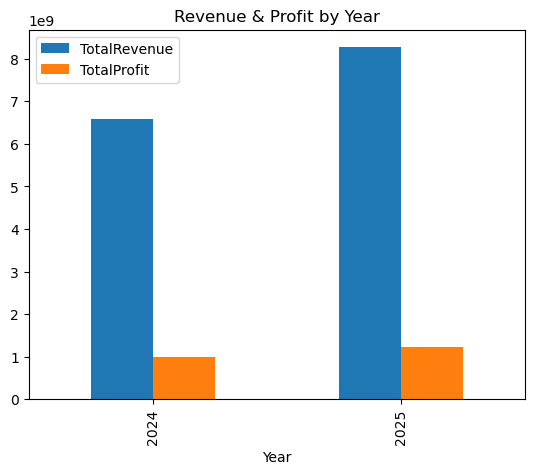

In [40]:
import matplotlib.pyplot as plt

summary_year.set_index('Year')[['TotalRevenue', 'TotalProfit']].plot(kind='bar')
plt.title('Revenue & Profit by Year')
plt.show()


--- Phân phối tần suất của Channel ---


Channel
Offline    1441
Online      926
Name: count, dtype: int64

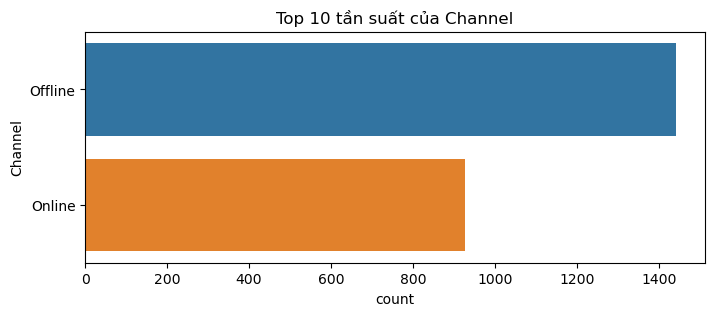


--- Phân phối tần suất của BranchID ---


BranchID
B11    140
B09    134
B04    133
B02    130
B05    126
B16    125
B13    124
B19    121
B12    120
B10    120
B08    119
B01    116
B03    116
B18    113
B07    113
B14    113
B15    109
B20    101
B06     99
B17     95
Name: count, dtype: int64

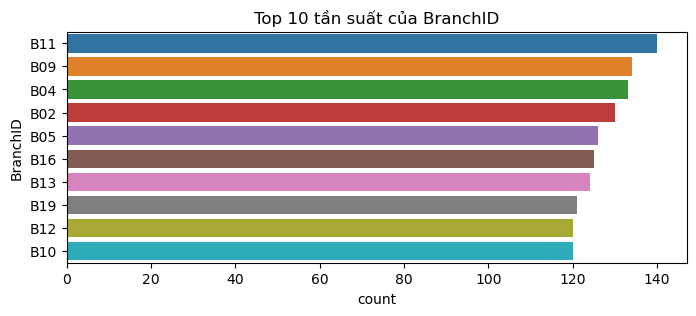


--- Phân phối tần suất của ProductID ---


ProductID
AC-1HP-CS      160
AC-15HP-CS     142
AC-1HP-CP      142
AC-15HP-CP     138
FAN-PANA-45    134
FAN-ASIA-40    132
WH-ROSSI-20    122
WH-ARIST-30    118
MW-PANA-25     117
RC-TOSH-18     117
WM-PANA-11     114
RC-SHARP-20    111
VAC-PANA-16    110
AIR-PURI-40    109
KTL-PANA-20    109
AIR-PURI-60    108
MW-SHARP-23    108
KTL-ELUX-17    104
WM-AQUA-9       86
VAC-ELUX-18     86
Name: count, dtype: int64

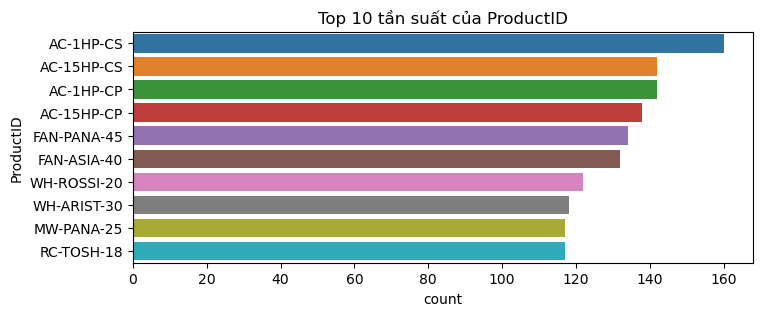

In [41]:
cat_cols = ['Channel', 'BranchID', 'ProductID']
for col in cat_cols:
    print(f'\n--- Phân phối tần suất của {col} ---')
    display(df[col].value_counts())
    plt.figure(figsize=(8, 3))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index[:10])
    plt.title(f'Top 10 tần suất của {col}')
    plt.show()


In [42]:
num_cols = ['Quantity', 'Revenue', 'Profit']
print('--- Mean (Trung bình) ---')
display(df[num_cols].mean())
print('\n--- Median (Trung vị) ---')
display(df[num_cols].median())
print('\n--- Mode (Yếu vị) ---')
display(df[num_cols].mode().iloc[0])


--- Mean (Trung bình) ---


Quantity    1.480777e+00
Revenue     6.270894e+06
Profit      9.410465e+05
dtype: float64


--- Median (Trung vị) ---


Quantity          1.0
Revenue     4430000.0
Profit       655000.0
dtype: float64


--- Mode (Yếu vị) ---


Quantity          1.0
Revenue     2114000.0
Profit       312000.0
Name: 0, dtype: float64

In [43]:
# thước đo biến thiên 
print('--- Range (Khoảng biến thiên) ---')
display(df[num_cols].max() - df[num_cols].min())
print('\n--- Variance (Phương sai) ---')
display(df[num_cols].var())
print('\n--- Standard Deviation (Độ lệch chuẩn) ---')
display(df[num_cols].std())
print('\n--- IQR (Khoảng tứ phân vị) ---')
iqr = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
display(iqr)


--- Range (Khoảng biến thiên) ---


Quantity           2.0
Revenue     23568000.0
Profit       3979000.0
dtype: float64


--- Variance (Phương sai) ---


Quantity    4.154165e-01
Revenue     2.919442e+13
Profit      6.765703e+11
dtype: float64


--- Standard Deviation (Độ lệch chuẩn) ---


Quantity    6.445281e-01
Revenue     5.403186e+06
Profit      8.225390e+05
dtype: float64


--- IQR (Khoảng tứ phân vị) ---


Quantity          1.0
Revenue     6698500.0
Profit       997500.0
dtype: float64

--- Skewness (Độ nghiêng) ---


Quantity    1.000579
Revenue     1.350262
Profit      1.408954
dtype: float64


--- Kurtosis (Độ nhọn) ---


Quantity   -0.120072
Revenue     1.275537
Profit      1.551206
dtype: float64

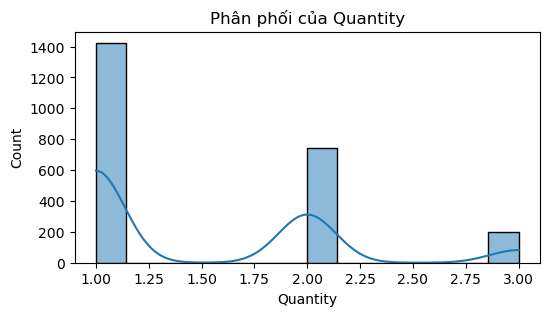

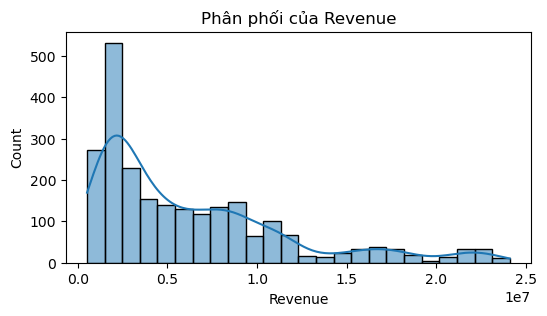

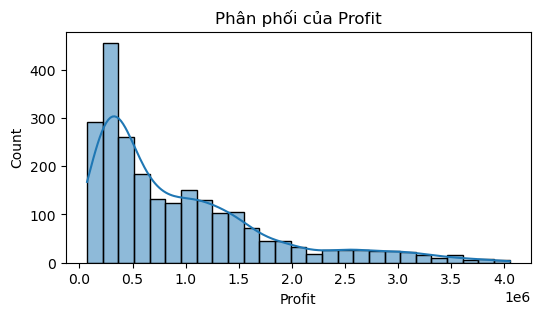

In [44]:
# thước đo hình thức 
print('--- Skewness (Độ nghiêng) ---')
display(df[num_cols].skew())
print('\n--- Kurtosis (Độ nhọn) ---')
display(df[num_cols].kurtosis())

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Phân phối của {col}')
    plt.show()


--- Covariance (Hiệp phương sai) ---


,Quantity,Revenue,Profit
Quantity,0.415416,6.705252e+05,1.038094e+05
Revenue,670525.221943,2.919442e+13,4.376578e+12
Profit,103809.431315,4.376578e+12,6.765703e+11



--- Correlation (Hệ số tương quan) ---


,Quantity,Revenue,Profit
Quantity,1.000000,0.192541,0.195812
Revenue,0.192541,1.000000,0.984755
Profit,0.195812,0.984755,1.000000


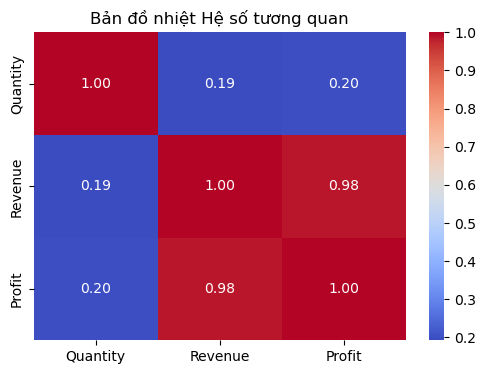

In [45]:
# thước đo  liên kết 
print('--- Covariance (Hiệp phương sai) ---')
display(df[num_cols].cov())
print('\n--- Correlation (Hệ số tương quan) ---')
corr_matrix = df[num_cols].corr()
display(corr_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Bản đồ nhiệt Hệ số tương quan')
plt.show()



#### xu hướng doanh thu theo thời gian


<Axes: xlabel='OrderDate'>

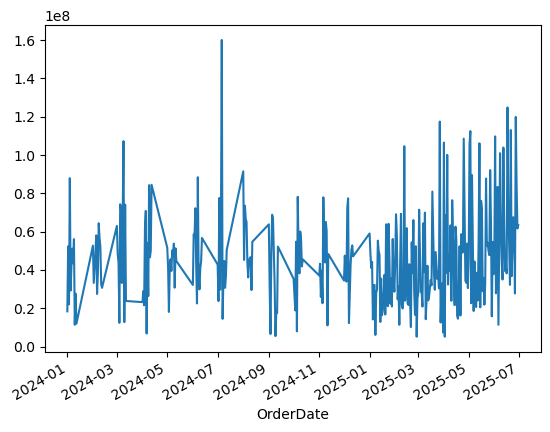

In [46]:
df.groupby('OrderDate')['Revenue'].sum().plot()

#### Nhận diện xu hướng mua sắm các mặt hàng trong năm 

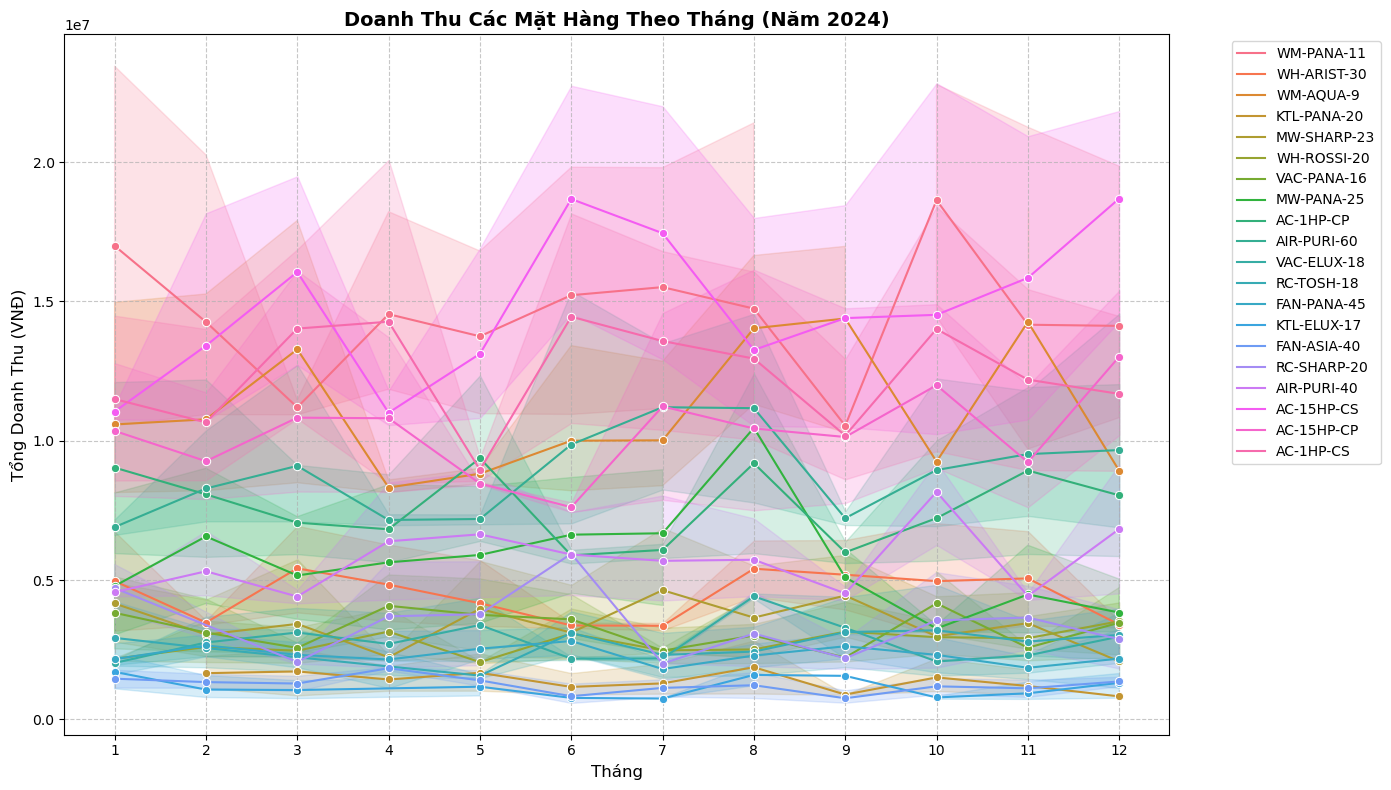

In [47]:
# Biểu đồ đường
plt.figure(figsize=(14, 8))
sns.lineplot(data=df1, x='Month', y='Revenue', hue='ProductID', marker='o')
plt.title('Doanh Thu Các Mặt Hàng Theo Tháng (Năm 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh Thu (VNĐ)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### so sánh doanh thu q1,2/2024 với q1,2/2025

In [48]:
# Lọc Q1, Q2 2024 và 2025 => xét xem xu hướng mua sp của 2024 và 2025 có sự thay đổi ntn
df_q1q2_24 = df1[df1['Month'].isin([1, 2, 3, 4, 5, 6])].copy()
df_q1q2_24['Year'] = '2024 (Q1+Q2)'

df_q1q2_25 = df2.copy()
df_q1q2_25['Year'] = '2025 (Q1+Q2)'

df_compare = pd.concat([df_q1q2_24, df_q1q2_25], ignore_index=True)
compare_revenue = df_compare.groupby(['ProductID', 'Year'])['Revenue'].sum().reset_index()


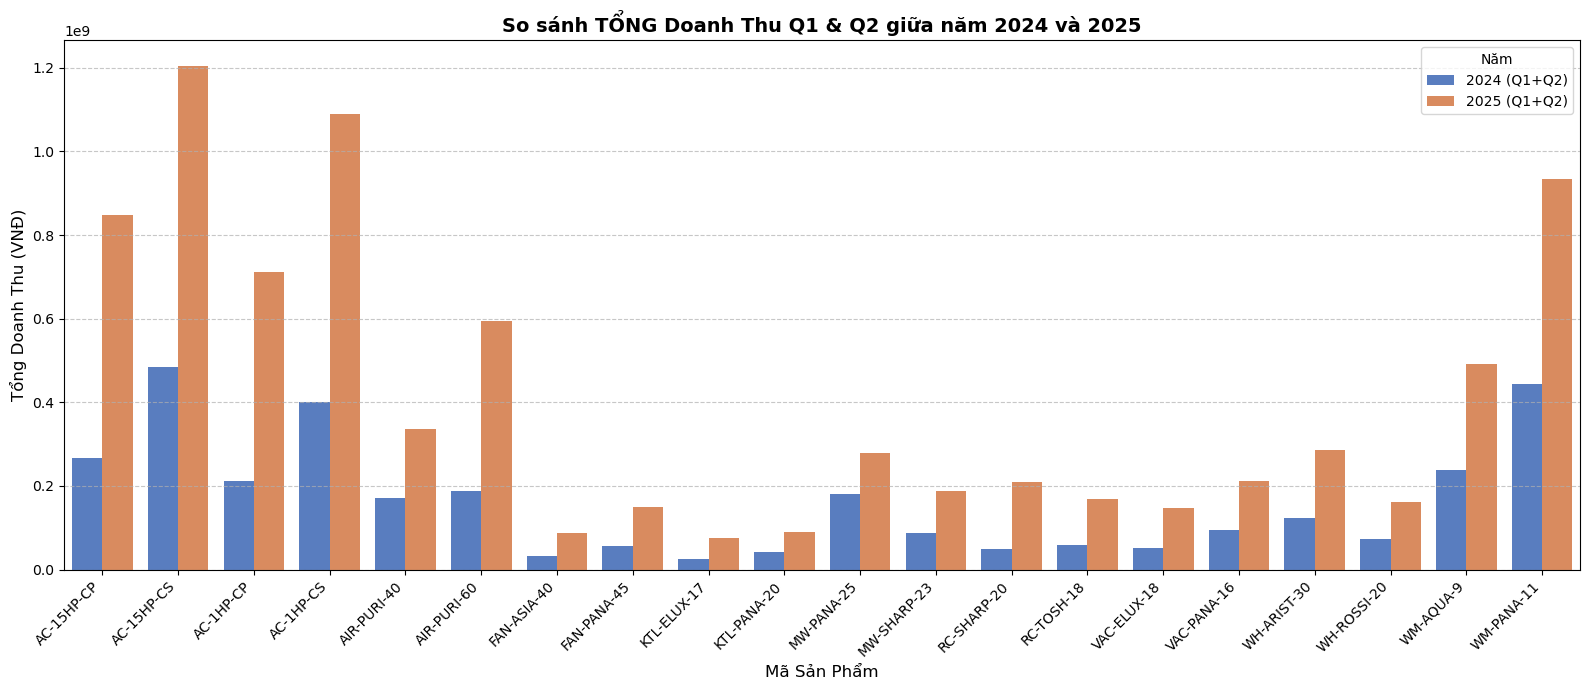

Year,2024 (Q1+Q2),2025 (Q1+Q2),Growth Rate (%)
ProductID,,,
RC-SHARP-20,49733000.0,2.082800e+08,318.80
AC-1HP-CP,212729000.0,7.122980e+08,234.84
AC-15HP-CP,266848000.0,8.490240e+08,218.17
AIR-PURI-60,186884000.0,5.940200e+08,217.85
KTL-ELUX-17,25448000.0,7.595900e+07,198.49
RC-TOSH-18,59038000.0,1.692470e+08,186.67
VAC-ELUX-18,51458000.0,1.461390e+08,184.00
FAN-ASIA-40,32398000.0,8.824700e+07,172.38
AC-1HP-CS,400552000.0,1.090116e+09,172.15


In [49]:

# Biểu đồ cột so sánh
plt.figure(figsize=(16, 7))
sns.barplot(data=compare_revenue, x='ProductID', y='Revenue', hue='Year', palette='muted')
plt.title('So sánh TỔNG Doanh Thu Q1 & Q2 giữa năm 2024 và 2025', fontsize=14, fontweight='bold')
plt.xlabel('Mã Sản Phẩm', fontsize=12)
plt.ylabel('Tổng Doanh Thu (VNĐ)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Năm')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Tính tỷ lệ tăng trưởng
pivot_compare = compare_revenue.pivot(index='ProductID', columns='Year', values='Revenue').fillna(0)
pivot_compare['Growth Rate (%)'] = ((pivot_compare['2025 (Q1+Q2)'] - pivot_compare['2024 (Q1+Q2)']) / pivot_compare['2024 (Q1+Q2)'] * 100).round(2)
display(pivot_compare.sort_values(by='Growth Rate (%)', ascending=False))



#### Định hướng chiến lược marketing

In [59]:
# # Sử dụng lại df_all chứa dữ liệu 2024 & 2025
# strategy_df = df_all.groupby('ProductID').agg(
#     Total_Revenue=('Revenue', 'sum'),
#     Total_Profit=('Profit', 'sum')
# ).reset_index()

# # Tính Profit Margin
# strategy_df['Profit_Margin_%'] = (strategy_df['Total_Profit'] / strategy_df['Total_Revenue'] * 100).round(2)

# # Xác định ngưỡng trung bình
# avg_revenue = strategy_df['Total_Revenue'].mean()
# avg_margin = strategy_df['Profit_Margin_%'].mean()

# # Phân loại 4 góc phần tư (Quadrants)
# def categorize_product(row):
#     if row['Total_Revenue'] >= avg_revenue and row['Profit_Margin_%'] >= avg_margin:
#         return 'Nên đẩy mạnh'
#     elif row['Total_Revenue'] >= avg_revenue and row['Profit_Margin_%'] < avg_margin:
#         return 'Tạo LN ổn định, tối ưu phí'
#     elif row['Total_Revenue'] < avg_revenue and row['Profit_Margin_%'] >= avg_margin:
#         return 'Cần marketing tăng Vol'
#     else:
#         return 'Cân nhắc loại bỏ/Giảm'

# strategy_df['Category'] = strategy_df.apply(categorize_product, axis=1)

# # Trực quan hóa Scatter Plot
# plt.figure(figsize=(14, 8))
# sns.scatterplot(
#     data=strategy_df, 
#     x='Total_Revenue', 
#     y='Profit_Margin_%', 
#     hue='Category', 
#     size='Total_Profit', 
#     sizes=(100, 2000), 
#     alpha=0.7, 
#     palette='Set1'
# )

# # Vẽ đường trung bình chia 4 góc phần tư
# plt.axvline(avg_revenue, color='gray', linestyle='--')
# plt.axhline(avg_margin, color='gray', linestyle='--')

# # Gắn tên cho các sản phẩm
# for i in range(strategy_df.shape[0]):
#     plt.text(x=strategy_df['Total_Revenue'][i], 
#              y=strategy_df['Profit_Margin_%'][i] + 0.5, 
#              s=strategy_df['ProductID'][i], 
#              fontdict=dict(color='black', size=9),
#              ha='center')

# plt.title('Ma trận Chiến lược: Doanh Thu vs Biên Lợi Nhuận', fontsize=16, fontweight='bold')
# plt.xlabel('Tổng Doanh Thu (VNĐ)', fontsize=12)
# plt.ylabel('Biên Lợi Nhuận (Profit Margin %)', fontsize=12)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle=':', alpha=0.6)
# plt.tight_layout()
# plt.show()




In [60]:
# # Hiển thị Tóm tắt Chiến lược
# print("--- KHUYẾN NGHỊ CHIẾN LƯỢC TỪ MA TRẬN ---\n")
# for cat in strategy_df['Category'].unique():
#     prods = strategy_df[strategy_df['Category'] == cat]['ProductID'].tolist()
#     print(f"[{cat}]: {', '.join(prods)}")


In [61]:
# # phân tích hiệu quả kênh bán hàng => đánh giá sự chuyển hành vi giữa tiêu dùng Onl và Off
# # Thêm thông tin Quý (Quarter) và Năm (Year) vào mức hiển thị, ví dụ '2024-Q1'
# df_all['OrderDate'] = pd.to_datetime(df_all['OrderDate'])
# df_all['Quarter'] = df_all['OrderDate'].dt.to_period('Q').astype(str)

# # 9.1. Thống kê tỷ lệ đơn hàng và lợi nhuận giữa Online và Offline qua các Quý
# channel_trend = df_all.groupby(['Quarter', 'Channel']).agg(
#     Orders=('OrderID', 'count'),
#     Profit=('Profit', 'sum')
# ).reset_index()

# # Biểu đồ xu hướng Đơn hàng theo Kênh qua các Quý
# plt.figure(figsize=(14, 6))
# plt.subplot(1, 2, 1)
# sns.lineplot(data=channel_trend, x='Quarter', y='Orders', hue='Channel', marker='o', linewidth=2)
# plt.title('Số lượng Đơn hàng: Online vs Offline', fontsize=12, fontweight='bold')
# plt.xlabel('Quý', fontsize=10)
# plt.ylabel('Số lượng Đơn hàng', fontsize=10)
# plt.grid(True, linestyle='--', alpha=0.5)

# # Biểu đồ xu hướng Lợi nhuận theo Kênh qua các Quý
# plt.subplot(1, 2, 2)
# sns.lineplot(data=channel_trend, x='Quarter', y='Profit', hue='Channel', marker='s', linewidth=2)
# plt.title('Lợi Nhuận: Online vs Offline', fontsize=12, fontweight='bold')
# plt.xlabel('Quý', fontsize=10)
# plt.ylabel('Lợi Nhuận (VNĐ)', fontsize=10)
# plt.grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

# # 9.2. Phân tích hành vi mua các sản phẩm đắt tiền theo Kênh
# # Tính giá trung bình mỗi sản phẩm: Revenue / Quantity
# df_all['Unit_Price'] = df_all['Revenue'] / df_all['Quantity']
# avg_price_by_product = df_all.groupby('ProductID')['Unit_Price'].mean().sort_values(ascending=False)

# # Xác định Top 5 sản phẩm đắt tiền nhất (máy lạnh, máy giặt, v.v)
# high_value_products = avg_price_by_product.head(5).index.tolist()
# print(f"Top 5 sản phẩm có đơn giá cao nhất: {high_value_products}")

# # Lọc dữ liệu nhóm sản phẩm đắt tiền này
# df_high_value = df_all[df_all['ProductID'].isin(high_value_products)]

# # Thống kê lượng mua (Orders) theo kênh của nhóm đắt tiền
# high_value_channel = df_high_value.groupby(['ProductID', 'Channel']).agg(Orders=('OrderID', 'count')).reset_index()

# plt.figure(figsize=(10, 6))
# sns.barplot(data=high_value_channel, x='ProductID', y='Orders', hue='Channel', palette='Set2')
# plt.title('Hành vi Chọn Kênh đối với Sản Phẩm Đắt Tiền (Máy giặt, Máy lạnh...)', fontsize=14, fontweight='bold')
# plt.xlabel('Mã Sản Phẩm', fontsize=12)
# plt.ylabel('Số lượng Đơn hàng', fontsize=12)
# plt.xticks(rotation=45)
# plt.legend(title='Kênh bán')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# # plt.show()

# # Hiển thị bảng tỷ trọng Online/Offline cho nhóm Đắt tiền
# pivot_hv = high_value_channel.pivot(index='ProductID', columns='Channel', values='Orders').fillna(0)
# pivot_hv['Total'] = pivot_hv['Offline'] + pivot_hv['Online']
# pivot_hv['Online_Ratio_%'] = (pivot_hv['Online'] / pivot_hv['Total'] * 100).round(1)
# pivot_hv['Offline_Ratio_%'] = (pivot_hv['Offline'] / pivot_hv['Total'] * 100).round(1)
# display(pivot_hv.sort_values(by='Online_Ratio_%', ascending=False))



In [62]:
# # hiệu suất chi nhánh => đánh giá sở thích theo vùng miền 
# # Thống kê tổng Số lượng bán ra của từng sản phẩm tại từng chi nhánh
# branch_product_sales = df_all.groupby(['BranchID', 'ProductID'])['Quantity'].sum().reset_index()

# # 11.1 Trực quan hóa Heatmap toàn cảnh
# # Pivot table để dễ so sánh: Dòng = Chi nhánh, Cột = Sản phẩm, Giá trị = Số lượng
# pivot_branch = branch_product_sales.pivot(index='BranchID', columns='ProductID', values='Quantity').fillna(0)
# plt.figure(figsize=(16, 10))
# sns.heatmap(pivot_branch, cmap='YlGnBu', linewidths=0.5)
# plt.title('Bản đồ Nhiệt: Mức độ Mua hàng theo Từng Chi nhánh & Sản phẩm', fontsize=14, fontweight='bold')
# plt.xlabel('Mã Sản Phẩm', fontsize=12)
# plt.ylabel('Mã Chi nhánh', fontsize=12)
# plt.tight_layout()
# plt.show()

<Axes: xlabel='OrderDate'>

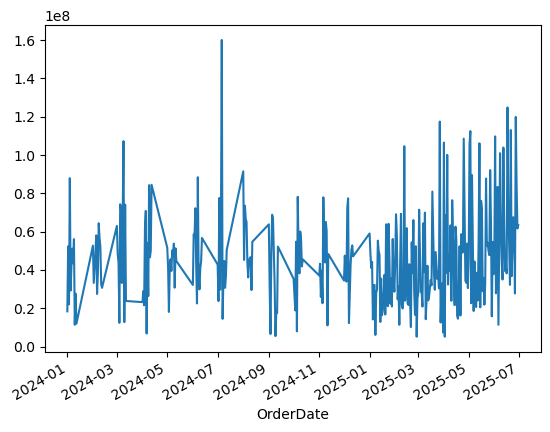

In [54]:
# doanh thu theo tg
df.groupby('OrderDate')['Revenue'].sum().plot()

<Axes: xlabel='Year'>

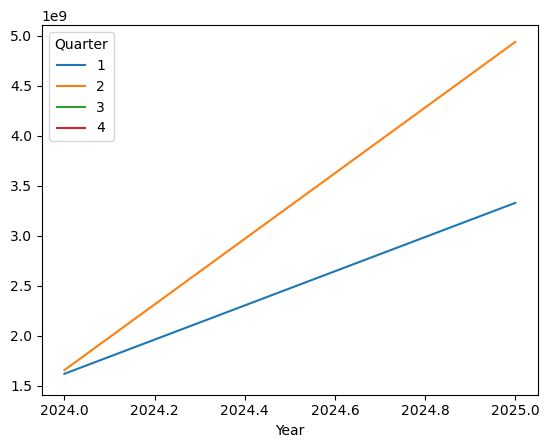

In [55]:
df.groupby(['Year','Quarter'])['Revenue'].sum().unstack().plot()

In [56]:
df.to_csv('Cleaned_Sales.csv', index=False)

In [57]:
growth = summary_year.copy()

growth[['Revenue_Growth_%', 'Profit_Growth_%', 'Orders_Growth_%']] = (
    summary_year[['TotalRevenue', 'TotalProfit', 'TotalOrders']]
    .pct_change() * 100
)

growth

,Year,TotalRevenue,TotalProfit,TotalOrders,Revenue_Growth_%,Profit_Growth_%,Orders_Growth_%
0,2024,6.574310e+09,9.890170e+08,1047,NaN,NaN,NaN
1,2025,8.268896e+09,1.238440e+09,1320,25.775876,25.219283,26.074499


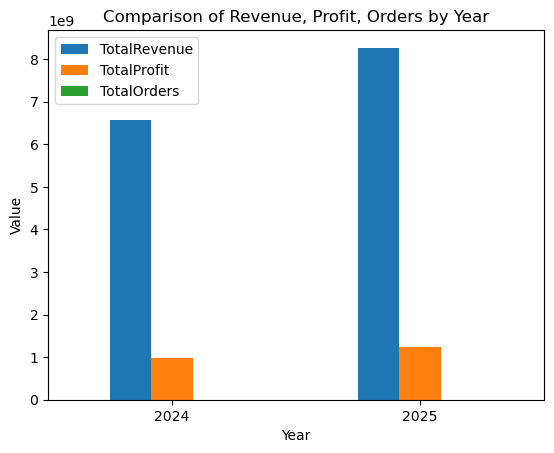

In [58]:
import matplotlib.pyplot as plt

summary_year.set_index('Year')[['TotalRevenue', 'TotalProfit', 'TotalOrders']].plot(kind='bar')

plt.title('Comparison of Revenue, Profit, Orders by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()

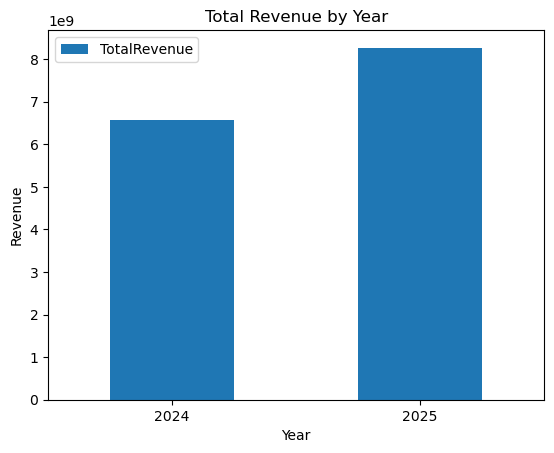

In [63]:
summary_year.plot(x='Year', y='TotalRevenue', kind='bar')

plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

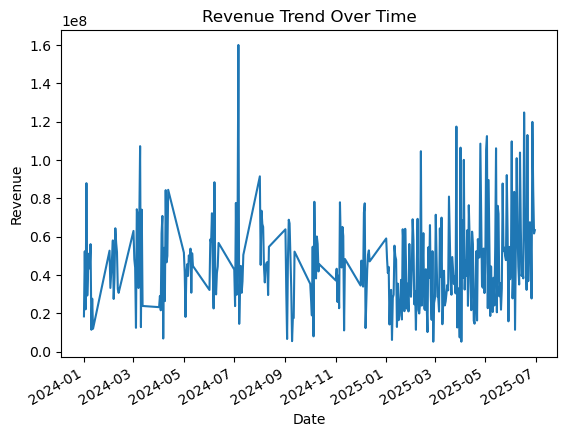

In [64]:
df.groupby('OrderDate')['Revenue'].sum().plot()

plt.title('Revenue Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

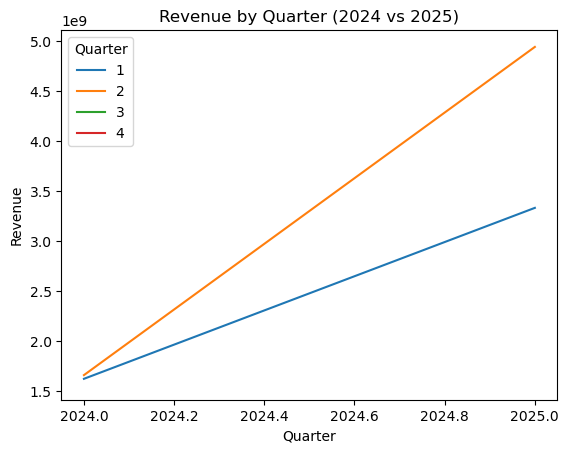

In [65]:
quarter = df.groupby(['Year','Quarter'])['Revenue'].sum().unstack()

quarter.plot()

plt.title('Revenue by Quarter (2024 vs 2025)')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.show()

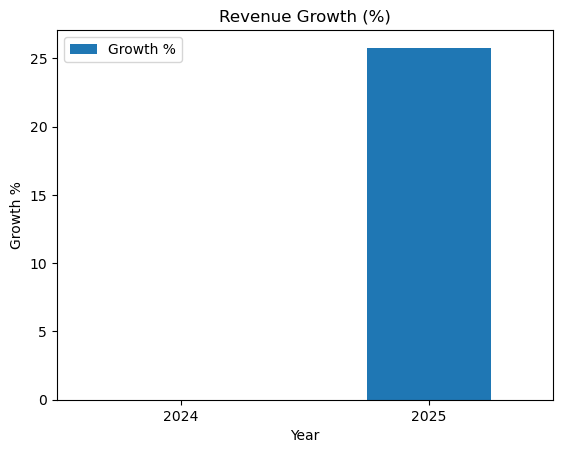

In [66]:
growth = summary_year[['Year', 'TotalRevenue']].copy()
growth['Growth %'] = growth['TotalRevenue'].pct_change() * 100

growth.plot(x='Year', y='Growth %', kind='bar')

plt.title('Revenue Growth (%)')
plt.xlabel('Year')
plt.ylabel('Growth %')
plt.xticks(rotation=0)
plt.show()

In [67]:
print(df1)

            OrderID  OrderDate    ProductID CustomerID BranchID  Quantity  \
0     2024-Q1-00001 2024-02-01   WM-PANA-11       C034      B04         2   
1     2024-Q1-00002 2024-10-02  WH-ARIST-30       C003      B11         2   
4     2024-Q1-00005 2024-07-02    WM-AQUA-9       C026      B19         1   
6     2024-Q1-00007 2024-06-02  KTL-PANA-20       C055      B02         2   
8     2024-Q1-00009 2024-03-02  MW-SHARP-23       C038      B01         1   
...             ...        ...          ...        ...      ...       ...   
2620  2024-Q4-00651 2024-07-11  KTL-PANA-20       C088      B17         1   
2621  2024-Q4-00652 2024-07-10  WH-ROSSI-20       C029      B04         1   
2625  2024-Q4-00656 2024-06-11  FAN-ASIA-40       C008      B07         1   
2627  2024-Q4-00658 2024-05-11   WM-PANA-11       C096      B02         1   
2629  2024-Q4-00660 2024-02-10   MW-PANA-25       C084      B11         2   

         Revenue     Profit  Channel  Year  Month  Quarter  
0     23204000

In [86]:
summary_year = df.groupby('Year').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
    # 'OrderID': 'nunique'
}).reset_index()

summary_year.rename(columns={
    'Revenue': 'TotalRevenue',
    'Profit': 'TotalProfit'
    # 'OrderID': 'TotalOrders'
}, inplace=True)

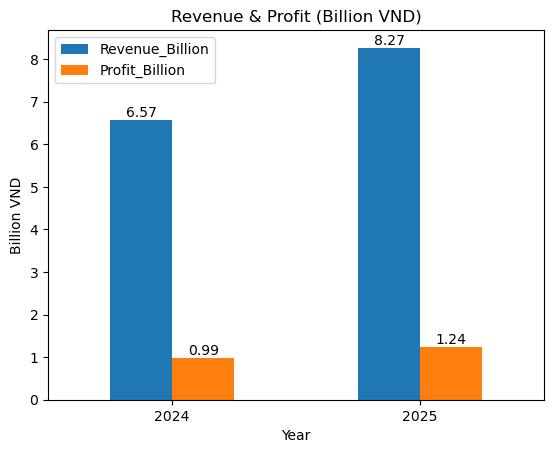

In [87]:
import matplotlib.pyplot as plt

# đổi đơn vị sang tỷ
summary_year['Revenue_Billion'] = summary_year['TotalRevenue'] / 1e9
summary_year['Profit_Billion'] = summary_year['TotalProfit'] / 1e9

ax = summary_year.set_index('Year')[['Revenue_Billion', 'Profit_Billion']].plot(kind='bar')

plt.title('Revenue & Profit (Billion VND)')
plt.xlabel('Year')
plt.ylabel('Billion VND')
plt.xticks(rotation=0)

# thêm label (2 chữ số thập phân)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

#### Biểu đồ cho thấy mối quan hệ giữa doanh thu và lợi nhuận, đồng thời kích thước bong bóng phản ánh số lượng đơn hàng.

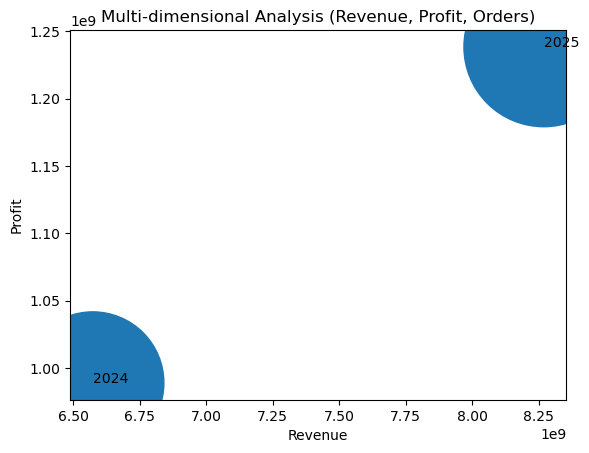

In [88]:
import matplotlib.pyplot as plt

# tổng hợp theo năm
multi = df.groupby('Year').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'OrderID': 'nunique'
}).reset_index()

plt.scatter(
    multi['Revenue'],
    multi['Profit'],
    s=multi['OrderID']*10,   # size
)

for i in range(len(multi)):
    plt.text(multi['Revenue'][i], multi['Profit'][i], str(multi['Year'][i]))

plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.title('Multi-dimensional Analysis (Revenue, Profit, Orders)')
plt.show()

#### Một số chi nhánh có doanh thu cao ổn định theo thời gian, trong khi một số khác biến động mạnh.

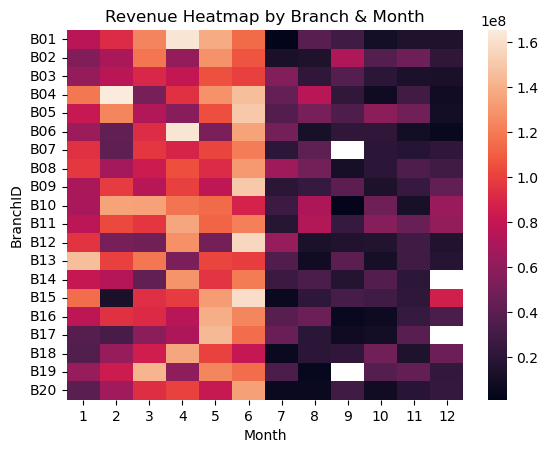

In [89]:
import seaborn as sns

pivot = df.pivot_table(
    values='Revenue',
    index='BranchID',
    columns='Month',
    aggfunc='sum'
)

sns.heatmap(pivot)
plt.title('Revenue Heatmap by Branch & Month')
plt.show()

#### BAR CHART – So sánh tổng theo năm
Năm 2025 ghi nhận sự thay đổi so với năm 2024, thể hiện qua sự chênh lệch về doanh thu, lợi nhuận và số lượng đơn hàng. Điều này cho thấy hiệu suất kinh doanh đã có sự biến động đáng kể giữa hai năm => Nếu doanh thu tăng nhưng lợi nhuận tăng chậm hơn, có thể chi phí đang gia tăng

### LINE CHART – Xu hướng theo tháng (2024 vs 2025)
Doanh thu có xu hướng biến động theo thời gian, trong đó năm 2025 nhìn chung cao hơn năm 2024 ở nhiều tháng, cho thấy sự tăng trưởng tích cực.
=> Một số tháng có sự sụt giảm so với năm trước, cho thấy yếu tố mùa vụ hoặc chiến lược kinh doanh chưa ổn định.

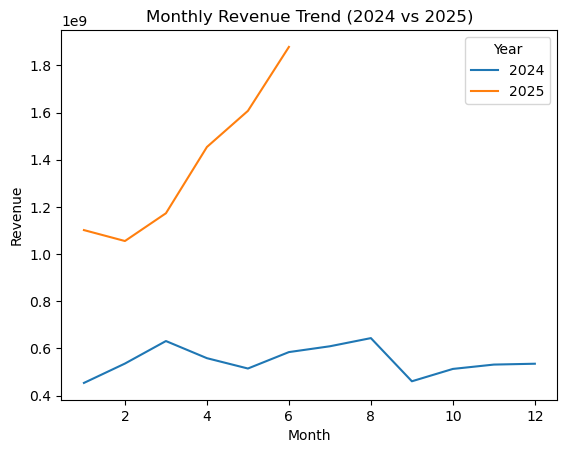

In [91]:
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()

pivot = monthly.pivot(index='Month', columns='Year', values='Revenue')

pivot.plot()

plt.title('Monthly Revenue Trend (2024 vs 2025)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

### COMBO CHART – Top 10 sản phẩm
Một số sản phẩm có số lượng đơn hàng cao nhưng doanh thu không tương ứng, cho thấy giá trị mỗi đơn hàng thấp
=> Ngược lại, một số sản phẩm có ít đơn nhưng doanh thu cao, cho thấy đây là nhóm sản phẩm giá trị cao cần được tập trung.

C:\Users\THANH HIEN\AppData\Local\Temp\ipykernel_29792\2433447960.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(top_product['ProductID'], rotation=45)


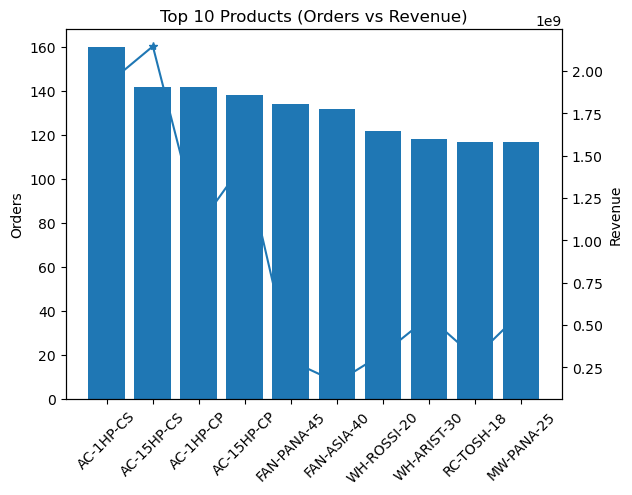

In [94]:
top_product = df.groupby('ProductID').agg({
    'OrderID': 'nunique',
    'Revenue': 'sum'
}).reset_index()

top_product = top_product.sort_values(by='OrderID', ascending=False).head(10)

fig, ax1 = plt.subplots()

# cột (orders)
ax1.bar(top_product['ProductID'], top_product['OrderID'])
ax1.set_ylabel('Orders')
ax1.set_xticklabels(top_product['ProductID'], rotation=45)

# đường (revenue)
ax2 = ax1.twinx()
ax2.plot(top_product['ProductID'], top_product['Revenue'], marker='*')
ax2.set_ylabel('Revenue')

plt.title('Top 10 Products (Orders vs Revenue)')
plt.show()

### Columns chart - orders theo quý


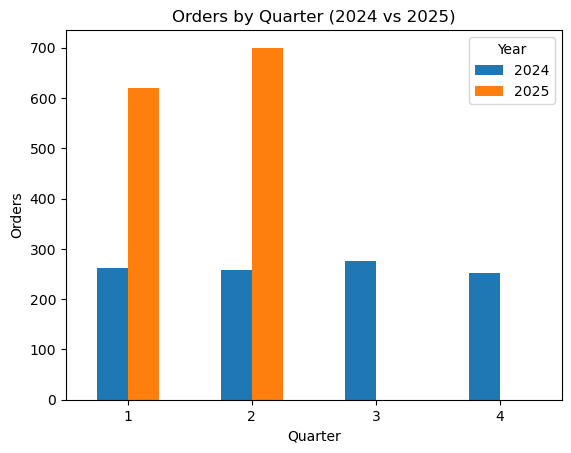

In [95]:
quarter = df.groupby(['Year','Quarter'])['OrderID'].nunique().reset_index()

pivot_q = quarter.pivot(index='Quarter', columns='Year', values='OrderID')

pivot_q.plot(kind='bar')

plt.title('Orders by Quarter (2024 vs 2025)')
plt.xlabel('Quarter')
plt.ylabel('Orders')
plt.xticks(rotation=0)
plt.show()

### Histogram - phân phối 


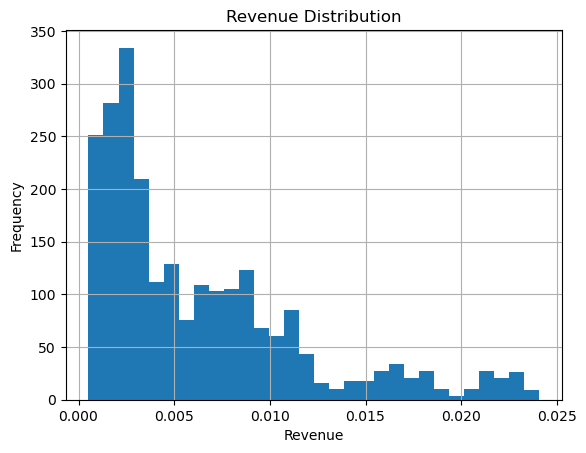

In [99]:
df['Revenue'].hist(bins=30)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

### BOXPLOT – Phân phối & Outlier

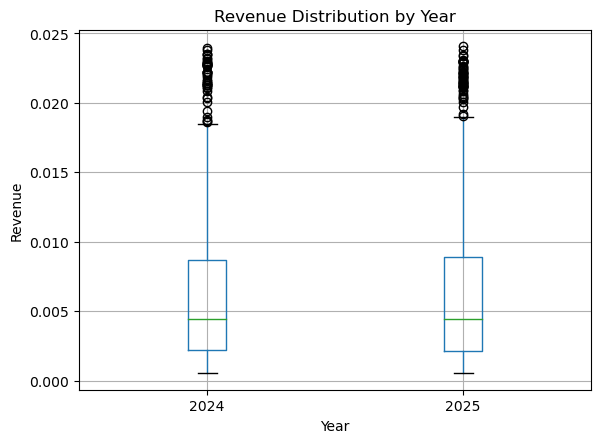

In [100]:
df.boxplot(column='Revenue', by='Year')
df = df.sort_values(by=['Year','Month'])

plt.title('Revenue Distribution by Year')
plt.suptitle('')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()